In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Comparison of Kempe Greedy vs. Welfare Greedy

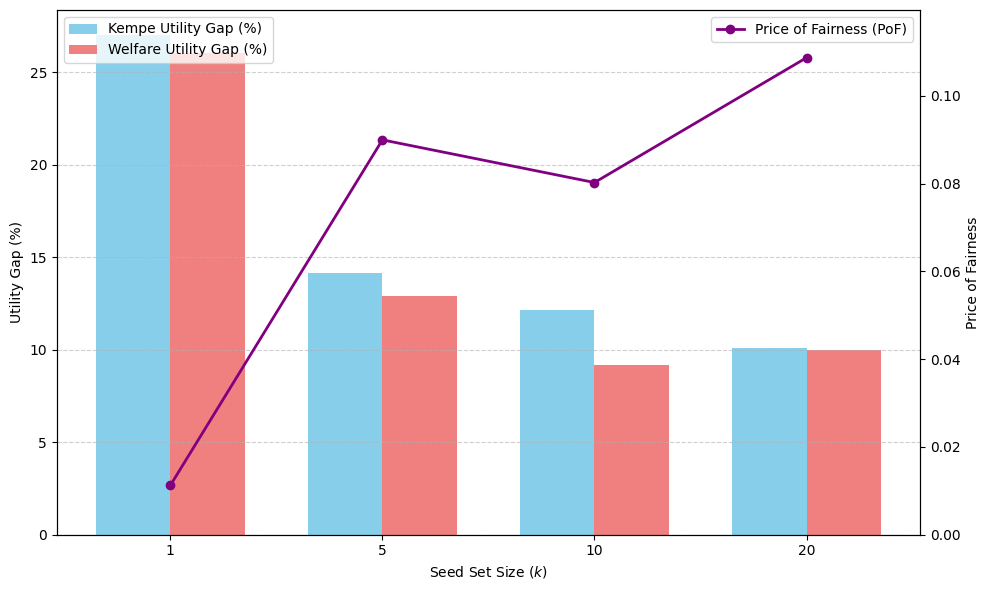

In [170]:
df_k_var = pd.read_csv('barbasi_albert/size_200/kempe_welfare_k_variation_barbasi_albert_200.csv')

# Compute utility gaps for both methods
def compute_utility_gap_percent(influence_dict_str):
    try:
        d = ast.literal_eval(influence_dict_str)
        if not d or sum(d.values()) == 0:
            return 0.0
        return (max(d.values()) - min(d.values())) / sum(d.values()) * 100
    except Exception:
        return 0.0

for method in ['kempe', 'welfare']:
    df_k_var[f'{method}_gap'] = df_k_var[f'{method}_influence_by_community'].apply(compute_utility_gap_percent)

# Bar chart + line plot
x = np.arange(len(df_k_var))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot utility gaps
ax1.bar(x - bar_width / 2, df_k_var['kempe_gap'], width=bar_width, label='Kempe Utility Gap (%)', color='skyblue')
ax1.bar(x + bar_width / 2, df_k_var['welfare_gap'], width=bar_width, label='Welfare Utility Gap (%)', color='lightcoral')
ax1.set_xlabel('Seed Set Size ($k$)')
ax1.set_ylabel('Utility Gap (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(df_k_var['k'])
ax1.legend(loc='upper left')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

# Plot PoF on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(x, df_k_var['price_of_fairness'], color='purple', marker='o', linewidth=2, label='Price of Fairness (PoF)')
ax2.set_ylabel('Price of Fairness')
ax2.set_ylim(0, max(df_k_var['price_of_fairness'].max(), 0.05) * 1.1)  # ensure non-zero range
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


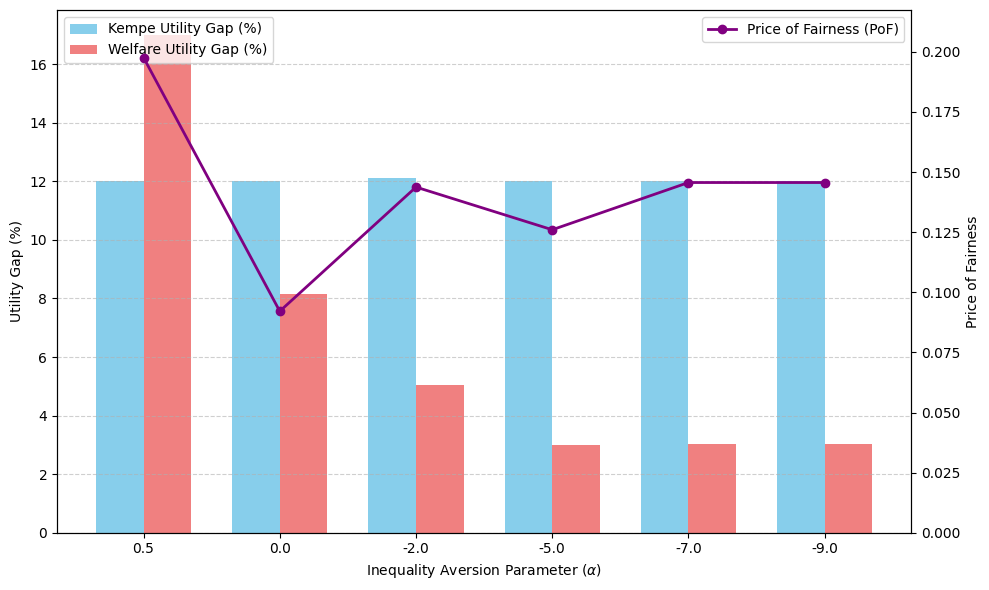

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_alpha_var = pd.read_csv('barbasi_albert/size_200/kempe_welfare_alpha_variation_barbasi_albert_200.csv')

# Safely compute utility gaps (normalized % difference)
def compute_utility_gap_percent(influence_dict_str):
    try:
        d = ast.literal_eval(influence_dict_str)
        if not d or sum(d.values()) == 0:
            return 0.0
        return (max(d.values()) - min(d.values())) / sum(d.values()) * 100
    except Exception:
        return 0.0

for method in ['kempe', 'welfare']:
    df_alpha_var[f'{method}_gap'] = df_alpha_var[f'{method}_influence_by_community'].apply(compute_utility_gap_percent)

# Bar chart and PoF line plot
x = np.arange(len(df_alpha_var))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot utility gap bars
ax1.bar(x - bar_width / 2, df_alpha_var['kempe_gap'], width=bar_width, label='Kempe Utility Gap (%)', color='skyblue')
ax1.bar(x + bar_width / 2, df_alpha_var['welfare_gap'], width=bar_width, label='Welfare Utility Gap (%)', color='lightcoral')
ax1.set_xlabel(r'Inequality Aversion Parameter ($\alpha$)')
ax1.set_ylabel('Utility Gap (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(df_alpha_var['alpha'])
ax1.legend(loc='upper left')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

# Plot PoF on twin axis
ax2 = ax1.twinx()
ax2.plot(x, df_alpha_var['price_of_fairness'], color='purple', marker='o', linewidth=2, label='Price of Fairness (PoF)')
ax2.set_ylabel('Price of Fairness')
ax2.set_ylim(0, max(df_alpha_var['price_of_fairness'].max(), 0.05) * 1.1)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


## Comparison of Welfare Greedy vs. Budgeted Welfare Greedy (CFIM)

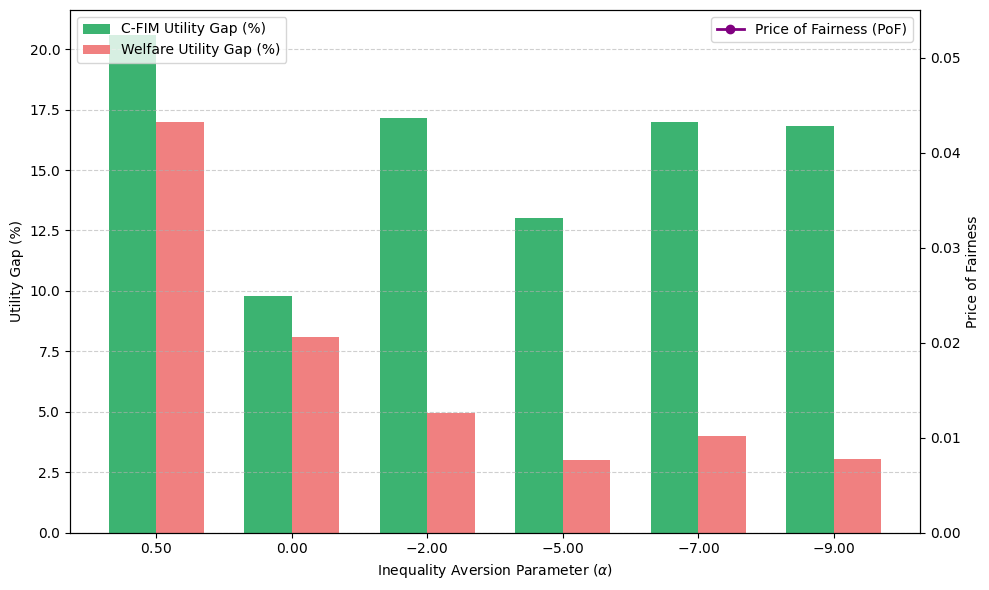

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

df_welfare_cfim = pd.read_csv('barbasi_albert/size_200/welfare_cfim_alpha_comparison_barbasi_albert_200.csv')

# Safely compute utility gap %
def compute_utility_gap_percent(influence_dict_str):
    try:
        d = ast.literal_eval(influence_dict_str)
        if not d or sum(d.values()) == 0:
            return 0.0
        return (max(d.values()) - min(d.values())) / sum(d.values()) * 100
    except Exception:
        return 0.0

# Apply utility gap calculation
for method in ['cfim', 'welfare']:
    df_welfare_cfim[f'{method}_gap'] = df_welfare_cfim[f'{method}_influence_by_community'].apply(compute_utility_gap_percent)

# Calculate Price of Fairness safely
df_welfare_cfim['PoF'] = 1 - (df_welfare_cfim['welfare_total_influence'] / df_welfare_cfim['cfim_total_influence'].replace(0, np.nan))
df_welfare_cfim['PoF'] = df_welfare_cfim['PoF'].fillna(0)  # In case of 0 influence baseline

# Plot setup
x = np.arange(len(df_welfare_cfim))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for utility gaps
ax1.bar(x - bar_width / 2, df_welfare_cfim['cfim_gap'], width=bar_width, label='C-FIM Utility Gap (%)', color='mediumseagreen')
ax1.bar(x + bar_width / 2, df_welfare_cfim['welfare_gap'], width=bar_width, label='Welfare Utility Gap (%)', color='lightcoral')
ax1.set_xlabel(r'Inequality Aversion Parameter ($\alpha$)')
ax1.set_ylabel('Utility Gap (%)')
ax1.set_xticks(x)
ax1.set_xticklabels([f"${a:.2f}$" for a in df_welfare_cfim['alpha']])  # nice LaTeX-style labels
ax1.legend(loc='upper left')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

# Line plot for PoF
ax2 = ax1.twinx()
ax2.plot(x, df_welfare_cfim['PoF'], color='purple', marker='o', linewidth=2, label='Price of Fairness (PoF)')
ax2.set_ylabel('Price of Fairness')
ax2.set_ylim(0, max(df_welfare_cfim['PoF'].max(), 0.05) * 1.1)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()